In [2]:
import numpy as np
import matplotlib.pyplot as plt

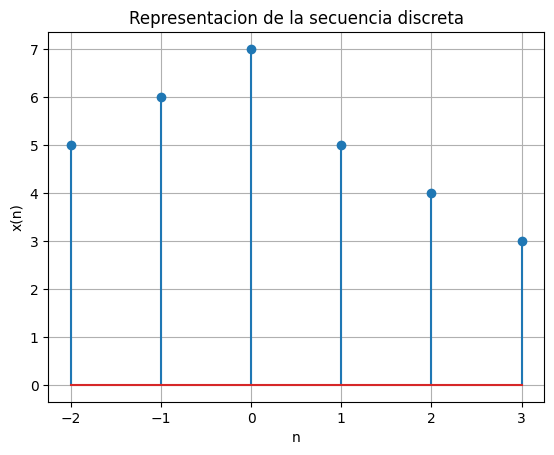

In [3]:
#Se definen los valores de la señal
n = np.array([-2,-1,0,1,2,3])
x = np.array([5,6,7,5,4,3])

#Graficamos la señal discreta
plt.stem(n,x)
plt.xlabel('n')
plt.ylabel('x(n)')
plt.title('Representacion de la secuencia discreta')
plt.grid(True)


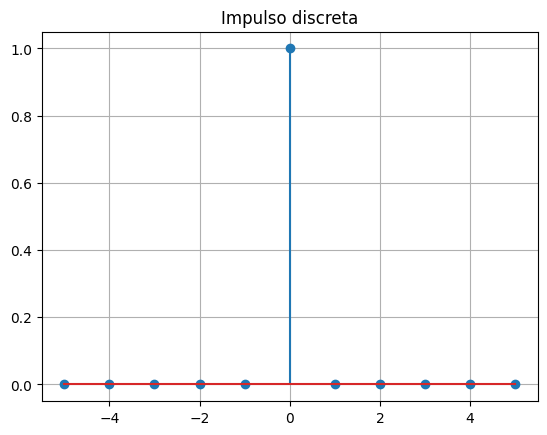

In [4]:
def impulso_unitario(n0,n1,n2):
    #n0 para este caso se define como 0 para que este sea el numero de la posicion inicial
    n = np.arange(n1,n2+1)
    x = (n==n0).astype(int) #La funcion astype permite convertir el vector resultante de n==n0 en un vector de enteros. 
    #[false,false,True,false,false] --> [0,0,1,0,0]
    return x,n
x,n = impulso_unitario(0,-5,5)
plt.stem(n,x)
plt.title("Impulso discreta")
plt.grid(True)

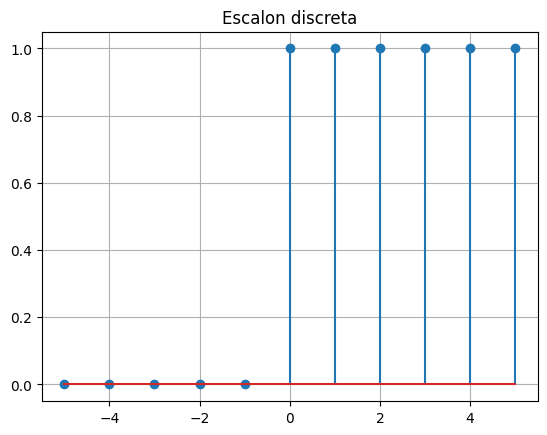

In [5]:

def escalon_unitario(n0,n1,n2):
    n = np.arange(n1,n2+1)
    x = (n>=n0).astype(int)
    return x,n

x,n = escalon_unitario(0,-5,5)
plt.stem(n,x)
plt.title("Escalon discreta")
plt.grid(True)




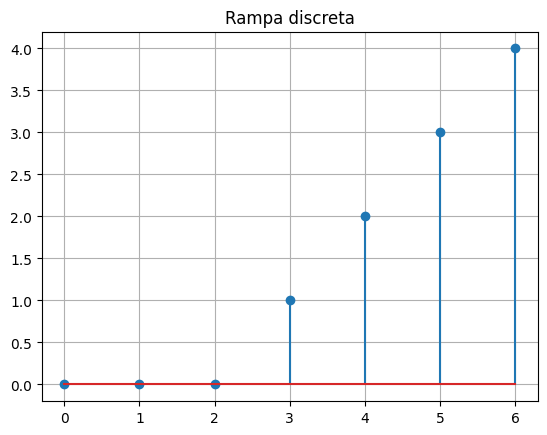

In [6]:
def rampa(t):
    return np.maximum(0,t)

t = np.arange(-2,5)
y=rampa(t)

plt.stem(y)
plt.title("Rampa discreta")
plt.grid(True)

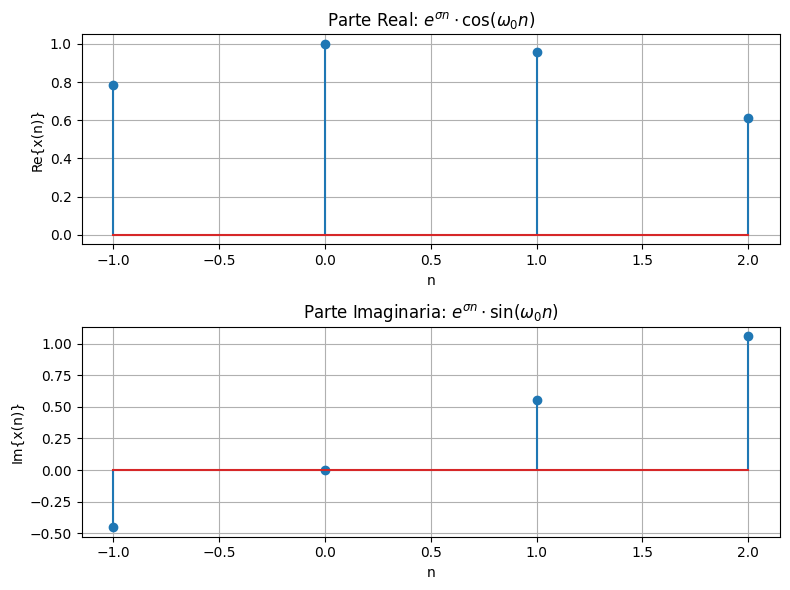

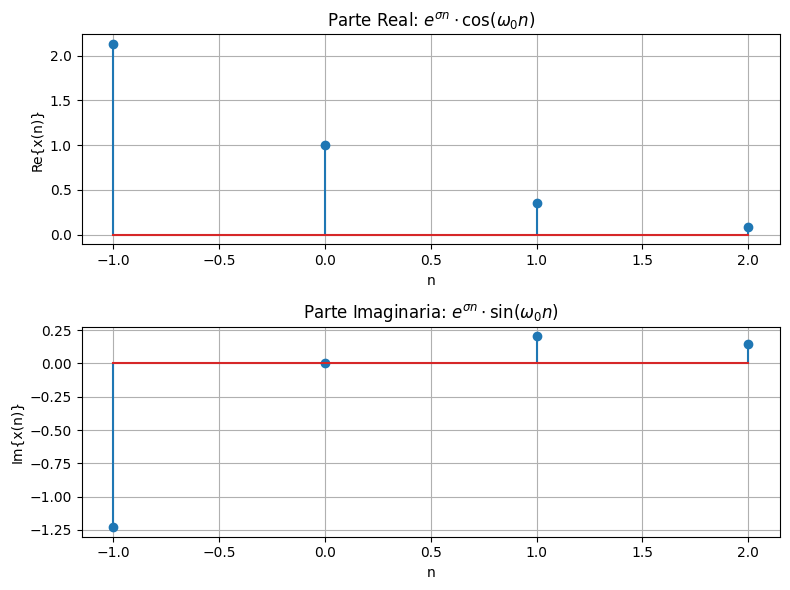

In [7]:
'''3. Implemente una función en Python que permita generar una función exponencial compleja,
definida en un intervalo 𝑛1≤𝑛0≤𝑛2. 

Las exponenciales complejas son de la forma: 𝑥(𝑛) = 𝑒^(𝜎+𝑗𝜔0)^𝑛, ∀ n.
En la que σ produce una atenuación si es negativo o una amplificación si es positivo. En Python
se hace uso del comando np.exp.
'''
n = np.array([-2,-1,0,1,2,3])
x = np.array([5,6,7,5,4,3])

def exp_compleja(n1,n2,n0, atenuacion, w0):
    n = np.arange(n1,n2+1) #Creación del vector entre los intervalos definidos
    x_exp = np.exp((atenuacion+1j*w0)*n) #Forma de exponenciales complejas, esta ecuación muestra que no tiene desplazamiento
    return x_exp, n                      #Sigma controla la amplitud, 1j*wo da la oscilación completa

x_exp,n = exp_compleja(-1,2,0,0.1,np.pi/6) #señal amplificada
fig, axs = plt.subplots(2,1,figsize=(8,6))
axs[0].stem(n, np.real(x_exp))
axs[0].set_title("Parte Real: $e^{\\sigma n} \\cdot \\cos(\\omega_0 n)$")
axs[0].set_xlabel('n')
axs[0].set_ylabel('Re{x(n)}')
axs[0].grid(True)

axs[1].stem(n, np.imag(x_exp))
axs[1].set_title("Parte Imaginaria: $e^{\\sigma n} \\cdot \\sin(\\omega_0 n)$")
axs[1].set_xlabel('n')
axs[1].set_ylabel('Im{x(n)}')
axs[1].grid(True)

plt.tight_layout()
plt.show()

x_exp,n = exp_compleja(-1,2,0,-0.9,np.pi/6) #señal atenuada
fig, axs = plt.subplots(2,1,figsize=(8,6))
axs[0].stem(n, np.real(x_exp))
axs[0].set_title("Parte Real: $e^{\\sigma n} \\cdot \\cos(\\omega_0 n)$")
axs[0].set_xlabel('n')
axs[0].set_ylabel('Re{x(n)}')
axs[0].grid(True)

axs[1].stem(n, np.imag(x_exp))
axs[1].set_title("Parte Imaginaria: $e^{\\sigma n} \\cdot \\sin(\\omega_0 n)$")
axs[1].set_xlabel('n')
axs[1].set_ylabel('Im{x(n)}')
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [8]:
# 4. Implemente una función en Python que permita generar una función sinusoidal, definida en un intervalo 𝑛1≤𝑛0≤𝑛2.
#Primero se debe crear una señal sinosoidal recordando que esta posee un omega 0 y un theta 0 que tambien deben ser dados pues estos representan frecuencia angular y fase inicial en rad
#La señal esta definida para n1<=n<=n2
def sinosoidal(n1,n2,n3,Ome_0,the_0):
    n = np.arange(n1,n2+10,n3)
    x = np.sin(Ome_0*n+the_0)

    fig, axs = plt.subplots(2, 1, figsize=(8, 6))

    axs[0].plot(n, x)
    axs[0].set_title('Señal Continua x(t)')
    axs[0].set_xlabel('t')
    axs[0].set_ylabel('Amplitud')
    axs[0].grid(True)

    axs[1].stem(n, x)
    axs[1].set_title('Señal Discreta x[n]')
    axs[1].set_xlabel('n')
    axs[1].set_ylabel('Amplitud')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    

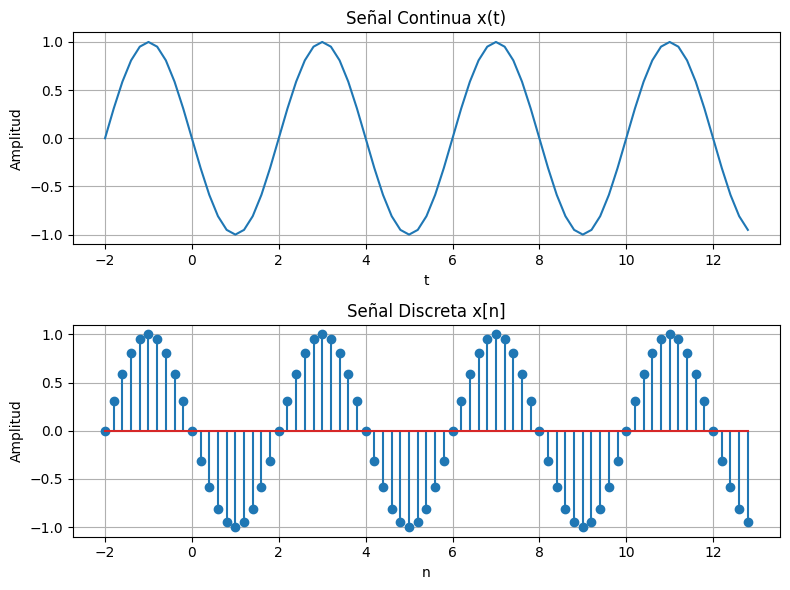

In [9]:
sinosoidal(-2,3,0.2,np.pi/2,np.pi)


In [10]:
'''Genere las siguientes secuencias usando las funciones básicas de Python que se han presentado. Grafique los resultados. 
x1(n)= 3𝛿(n+1)+5𝛿(n+3)+3𝛿(n+2)+3𝛿(n)+ 𝛿(n). ¿Cómo debe ser el vector de muestras?
Se trata de impulsos desplazados de la forma δ(n-k) en donde el impulso sera 1 cuando n = k
δ(n+1) --> n+1=0 --> n=-1 y asi sucesivamente con los demas impulsos
Adicionalmente 3δ(n)+δ(n) = 4δ(n) entonces en otros terminos la señal puede describirse en los siguientes rangos
x1(n) = 5 si n=-3, 3 si n=-2, 3 si n=-1 , 4 si n = 0 y 0 para cualquier otro caso
El vector de muestras por lo tanto debe ir desde el numero inferior osea -3 hasta el maximo osea 0, por lo que el vector resultante debe ser:
n=[-3,-2,-1,0]'''

def secuencia(n1,n2):
    
    #Se debe generar la señal: x1(n)=3δ(n+1)+5δ(n+3)+3δ(n+2)+4δ(n)
    x1, n = impulso_unitario(-1, n1, n2)
    x2, _ = impulso_unitario(-3, n1, n2)
    x3, _ = impulso_unitario(-2, n1, n2)
    x4, _ = impulso_unitario( 0, n1, n2)

    #En x1, n ; n sera el vector de muestras
    #Para x2,x3,x4 se usa el simbolo _ debido a que el vector n sera el mismo por lo que no es necesario capturarlo nuevamente


    # Sumar con sus respectivas amplitudes
    x = 3*x1 + 5*x2 + 3*x3 + 4*x4

    return n,x
        


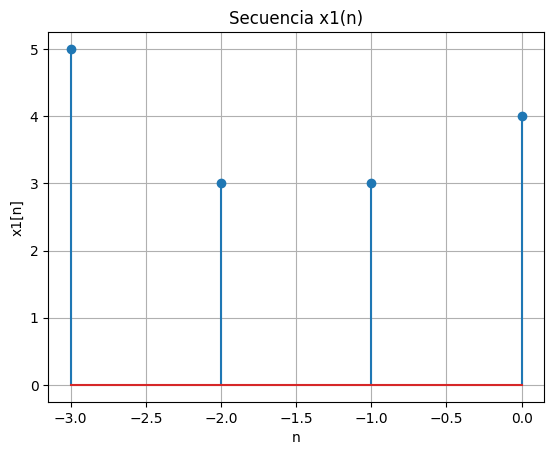

In [11]:
n1=-3
n2=0
n,x=secuencia(n1,n2)
plt.stem(n, x)  
plt.xlabel('n')
plt.ylabel('x1[n]')
plt.title('Secuencia x1(n)')
plt.grid(True)
plt.show()

In [12]:
'''Generar la secuencia x(n) = r[n] si 0 <= n <= 5 , r(n-5) si 6 <=n<=11 y r(n-10) si 12 <=n<=17
Adicionalmente derivar la secuencia
Realice un subplot con las dos secuencias, la original, y la derivada. Describa lo que observa y el porqué no es exactamente la derivada del caso continuo.
La rampa descrita es una rampa iniciada en 0 hasta 5, luego comienza otra rampa desde 6 hasta 11 y finalmente una rampa desde 12 hasta 17
Es una señal a tramos con una longitud de 6 en cada tramo, visualmente se espera que las rampas sean consecutivas'''

#Se crea un vector n que vaya de 0 hasta 18 que son el numero de muestras que nos estan dando
n = np.arange(0,18)
# Se crea un vector de zeros de la misma dimension que el vector que cumpla que en todas las posiciones donde la condición sea verdadera, se pondran unos valores valores
x = np.zeros_like(n)

# Bloque 1
#Aqui se puede ver la asignacion en el vector de zeros en donde a los indices de x que cumplan la condicion dada se les asignara el valor al otro lado de la igualdad
x[(n>=0)&(n<=5)] = rampa(n[(n>=0)&(n<=5)])

# Bloque 2
x[(n>=6)&(n<=11)] = rampa(n[(n>=6)&(n<=11)] - 5)

# Bloque 3
x[(n>=12)&(n<=17)] = rampa(n[(n>=12)&(n<=17)] - 10)

In [13]:
dx = np.zeros_like(x)
#La derivada discreta mide Cuánto cambia la señal entre una muestra y la siguiente.
# En otras palabras Si la señal sube de 2 a 3 → derivada = 1 , si la señal baja de 5 a 1 → derivada = -4, Si no cambia → derivada = 0
'''Lo que hace es tomar todas las muestras desde la posición 1 hasta el final (x[1:]) y restarles las muestras anteriores correspondientes (x[:-1]), que van desde la posición 0 hasta la penúltima. 
De esta manera se calcula, para cada n>=1, la diferencia x[n]-x[n-1]  que representa cuánto cambia la señal entre una muestra y la anterior.'''
dx[1:] = x[1:] - x[:-1]
#El resultado se almacena en dx desde la posición 1 en adelante, dejando dx[0] sin modificar (generalmente en cero) porque en n=0 no existe una muestra previa.

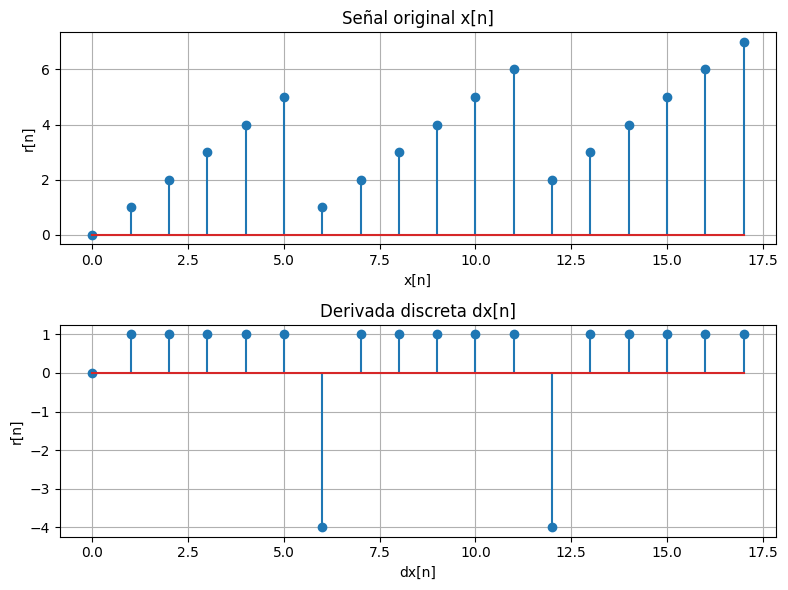

In [14]:
plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
plt.stem(n, x)
plt.title('Señal original x[n]')
plt.xlabel('x[n]')
plt.ylabel('r[n]')
plt.grid(True)

plt.subplot(2,1,2)
plt.stem(n, dx)
plt.title('Derivada discreta dx[n]')
plt.xlabel('dx[n]')
plt.ylabel('r[n]')
plt.grid(True)

plt.tight_layout()
plt.show()

En la grafica  de la señal original es posible ver como cada una de las rampas son crecientes comenzando en cada uno de sus valores correspondientes
la primera rampa comienza en 0 y termina en 5, sin embargo la segunda comienza en 6 sin embargo en el eje de r[n] comienza en 1, esto es debido a que
para el segundo tramo se tiene la definicion x[n]=r[n-5] por lo que cuando x[6] --> x[6]=r[6-5]=r[1] lo que explica que la segunda rampa comienze desplazada una unidad en el eje
vertical.
Para el caso de la tercera rampa se tiene el mismo caso, la cual comienza en su posicion de 12 sin embargo esta definida como x[n]=r[n-10], por lo que
x[12]=r[12-10]=r[2] lo que concuerda con lo visualizado graficamente

En el caso de la grafica para la derivada discreta, se puede observar una diferencia significativa debido a lo mencionado anteriormente
La derivada discreta mide Cuánto cambia la señal entre una muestra y la siguiente.
Por lo que la rampa al ir aumentando una unidad entre cada muestra tendra eso precisamente en su dereivada, una sola muestra de diferencia, esto hasta que ocurre el reinicio de rampa que es cuando la otra rampa comienza su ciclo en este caso la rampa no va en aumento sino que decrece un numero de unidades en particular que equivale al resultado de evaluar x[n]=r[n-m] respectivo, siendo m el desplazamiento dicho en la funcion a tramos, para el caso de la segunda rampa x[n]=r[n-5] cuando x[6] = r[1] y la diferencia entre la muestra anterior que era x[5] = r[5] y esta muestra es de -4 unidades por lo que se puede ver en este punto, un decrecimiento de esas unidades que corresponden a la diferencia con respecto a la muestra anterior, lo mismo sucede en x[12], en este caso r[2] pero en x[11] = r[6] por lo que tmabien se vera una disminucion de 4 unidades lo que se puede observar graficamente

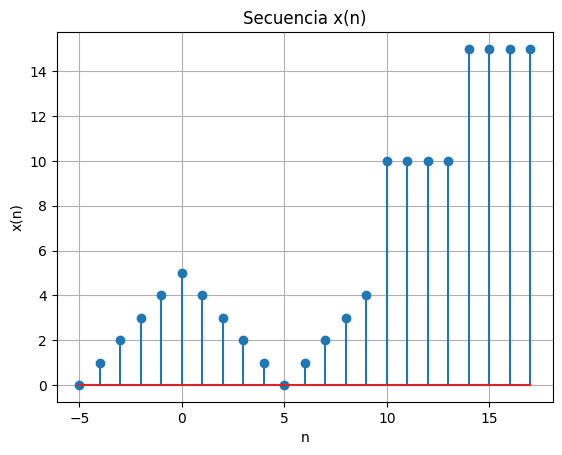

In [15]:
'''Sea 𝑥(𝑛) = {0,1,2,3,4, 5̂,4,3,2,1,0,1,2,3,4,5,5,5,5,10,10,10,10}. Genere la secuencia anterior y
grafique los resultados. Use las funciones que generó antes para generar la secuencia
concatenando secuencias más simples. Además, encuentre las siguientes secuencias:
'''
#El n=0 es 5, que está en la posición 5 del array x(n)
n= np.arange(-5,18) #Teniendo en cuenta que n=0 era x(n)=5, el rango de n va de -5 a 18
x_n = np.array([0,1,2,3,4,5,4,3,2,1,0,1,2,3,4,5,5,5,5,10,10,10,10])
x = (rampa(n+5)  #Señal acorde a rampa y constantes donde se puede utilizar el escalón unitario desplazado
     -2*rampa(n) 
     +2*rampa(n-5) 
     -rampa(n-10)
     +5*escalon_unitario(10,-5,17)[0]
     +5*escalon_unitario(14,-5,17)[0])

# gráfica
plt.figure()
plt.stem(n,x)
plt.title("Secuencia x(n)")
plt.xlabel("n")
plt.ylabel("x(n)")
plt.grid(True)

#La secuencia está conformada por dos rampas crecientes (n=[-5,0] y n=[5;10]), una rampa decreciente
#(n=[0,5]). Además de dos tramos constantes, 5 entre n=[10,13] y 10 entre n=[14,17]

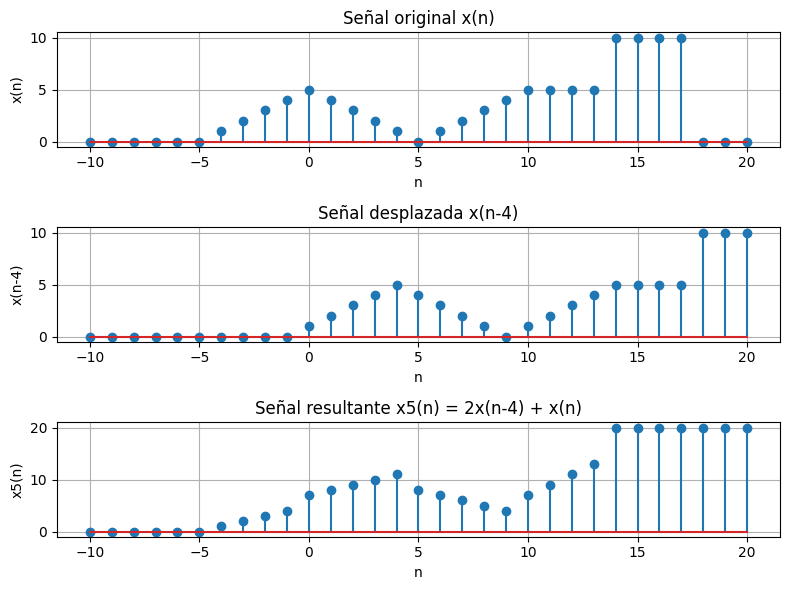

In [19]:
#Siguientes secuencias
# En el ejercicio a. se encuentra un desplazamiento temporal, multiplicado por el escalar 2
# Este desplazamiento se suma a la anterior secuencias, por lo que sumamoss las secuecias

# Se genera la señal desplazada, la cual corresponde a un desplazamiento temporal
# de cuatro muestras hacia la derecha. Luego, se amplifica por 2. Finalmente se realiza la suma
# con la secuencia x(n)

n = np.arange(-10,21)  #Vector más grande para observar el desplazamiento
x = np.zeros_like(n) #Almacena la señal original
x[-5-n[0]:-5-n[0]+len(x_n)] = x_n #Se agrega a x_n los valores de la señal

#Se realiza el desplazamiento temporal
x_desplazada= np.zeros_like(x) #Vector de ceros para almacenar  vector desplazado
x_desplazada[4:] = x[:-4]

x5_n =2*x_desplazada + x #Según la secuencia

plt.figure(figsize=(8,6))

plt.subplot(3,1,1)
plt.stem(n,x)
plt.title("Señal original x(n)")
plt.xlabel("n")
plt.ylabel("x(n)")
plt.grid(True)

plt.subplot(3,1,2)
plt.stem(n,x_desplazada)
plt.title("Señal desplazada x(n-4)")
plt.xlabel("n")
plt.ylabel("x(n-4)")
plt.grid(True)

plt.subplot(3,1,3)
plt.stem(n,x5_n)
plt.title("Señal resultante x5(n) = 2x(n-4) + x(n)")
plt.xlabel("n")
plt.ylabel("x5(n)")
plt.grid(True)

plt.tight_layout()
plt.show()


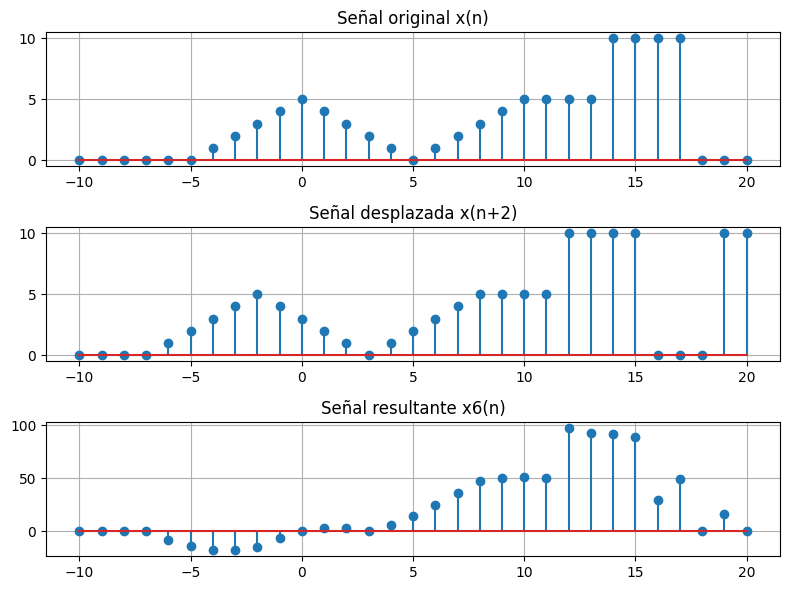

In [21]:
#b. x6(n) = 0.001e^(0.5n)x(n) + 10sin(0.05πn)x(n+2)
exponencial = 0.001*np.exp(0.5*n)*x #Parte exponencial
x_desplazada[:-2]=x[2:] #Parte desplazada 2 muestras hacia la izquierda
sen = 10*np.sin(0.05*np.pi*n)*x_desplazada

x6 = exponencial+sen #Señal final

plt.figure(figsize=(8,6))

plt.subplot(3,1,1)
plt.stem(n,x)
plt.title("Señal original x(n)")
plt.grid(True)

plt.subplot(3,1,2)
plt.stem(n,x_desplazada)
plt.title("Señal desplazada x(n+2)")
plt.grid(True)

plt.subplot(3,1,3)
plt.stem(n,x6)
plt.title("Señal resultante x6(n)")
plt.grid(True)

plt.tight_layout()
plt.show()